In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
from IPython.display import clear_output
import matplotlib.pyplot as plt

# import mlflow
# from mlflow.models import infer_signature
# mlflow.set_tracking_uri('http://127.0.0.1:8080')

In [16]:
import torch.utils
from torch.utils.data import ConcatDataset

torch.manual_seed(42)

# 定义两个不同的 transform：一个是原始的，一个是带有数据增强的
transform_original = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 定义带有数据增强的 transform
transform_augmented = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 加载两个版本的数据集，一个没有数据增强，一个有数据增强
trainset_original = torchvision.datasets.Flowers102(root='./data', split="test", download=True, transform=transform_original)
trainset_augmented = torchvision.datasets.Flowers102(root='./data', split="test", download=True, transform=transform_augmented)
# 使用ConcatDataset将两个数据集合并
merged_trainset = ConcatDataset([trainset_original, trainset_augmented])

train_loader = torch.utils.data.DataLoader(merged_trainset, batch_size=32, shuffle=True, num_workers=4)

testset = torchvision.datasets.Flowers102(root='./data', split="train", download=True, transform=transform_original)

# validation_size = int(0.5 * len(testset))  # 使用50%的test数据作为验证集
# test_size = validation_size

# testset, valset = torch.utils.data.random_split(testset, [test_size, validation_size])
test_loader = torch.utils.data.DataLoader(testset, batch_size=32, shuffle=False, num_workers=4)

valset = torchvision.datasets.Flowers102(root='./data', split="val", download=True, transform=transform_original)
val_loader = torch.utils.data.DataLoader(valset, batch_size=32, shuffle=False, num_workers=4)

print(len(merged_trainset),"\n", len(testset),'\n', len(valset))


12298 
 1020 
 1020


In [260]:
import torch
import torch.nn as nn

activationF = nn.ReLU()

In [17]:
import torch
import torch.nn as nn

class BasicBlock(nn.Module):
    expansion = 1  # For this block, the output channels are not expanded

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # First conv layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second conv layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # self.relu = nn.ReLU(inplace=True)
        # self.leaky_relu = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        self.silu = nn.SiLU(inplace=True)

        # If the input and output channels don't match, we adjust with a 1x1 convolution
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        # out = torch.relu(self.bn1(self.conv1(x)))  # First conv layer + ReLU
        # out = self.leaky_relu(self.bn1(self.conv1(x)))  # First conv layer + LeakyReLU
        out = self.silu(self.bn1(self.conv1(x)))  # First conv layer + SiLU
        out = self.bn2(self.conv2(out))  # Second conv layer
        
        # Add the shortcut connection (skip connection)
        out += self.shortcut(x)
        # out = torch.relu(out)
        # out = self.leaky_relu(out)
        out = self.silu(out)
        return out


In [18]:
device = torch.device("cuda"if torch.cuda.is_available() else "cpu")

class Net(nn.Module):
    def __init__(self, block, num_blocks, num_classes=102):
        super(Net, self).__init__()
        self.in_channels = 64

        # Initial convolutional layer
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        # self.relu = nn.ReLU(inplace=True)
        # self.leaky_relu = nn.LeakyReLU(negative_slope=0.01, inplace=True)
        self.silu = nn.SiLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # Residual layers
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # Fully connected layer for classification
        self.fc = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        # x = torch.relu(self.bn1(self.conv1(x)))
        # x = self.leaky_relu(self.bn1(self.conv1(x)))
        x = self.silu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x
    
net = Net(BasicBlock, [3, 4, 6, 3]).to(device)

In [19]:
import torch.optim as optim

# 使用交叉熵损失函数
criterion = nn.CrossEntropyLoss()

# 使用 Adam 优化器
# optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=0.0005)
optimizer = optim.NAdam(net.parameters(), lr=0.0001, weight_decay=0.0005)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=7)

In [20]:
# 加載檢查點函數
def load_checkpoint(filepath):
    checkpoint = torch.load(filepath)
    net.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch']
    epoch_train_losses = checkpoint.get('train_losses', [])
    epoch_val_losses = checkpoint.get('val_losses', [])
    epoch_train_accuracies = checkpoint.get('train_accuracies', [])
    epoch_val_accuracies = checkpoint.get('val_accuracies', [])
    epoch_learning_rates = checkpoint.get('learning_rates', [])
    print(f"模型已從第 {start_epoch} 代恢復。")
    return start_epoch, epoch_train_losses, epoch_val_losses, epoch_train_accuracies, epoch_val_accuracies, epoch_learning_rates

# 保存檢查點函數
def save_checkpoint(state, filename='checkpoint.pth'):
    torch.save(state, filename)

In [22]:
print("[INFO] Using device: ",  torch.cuda.get_device_name(torch.cuda.current_device()), f", device num:{torch.cuda.current_device}")
# net.load_state_dict(torch.load('./checkpoint.pth')['model_state_dict'])

def evaluate_model(net, val_loader):
    net.eval()  # 设置模型为评估模式
    val_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # 禁用梯度计算
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            # 前向传播
            outputs = net(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # 计算准确率
            correct_predictions += (torch.max(outputs, 1)[1] == labels).sum().item()
            total_samples += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)  # 计算平均验证损失
    val_accuracy = correct_predictions / total_samples  # 计算验证集准确率
    return avg_val_loss, val_accuracy
    # print(f'Accuracy: {100 * correct / total:.2f}%')


# evaluate_model(net, val_loader)

[INFO] Using device:  NVIDIA GeForce RTX 3090 , device num:<function current_device at 0x797af03c2160>


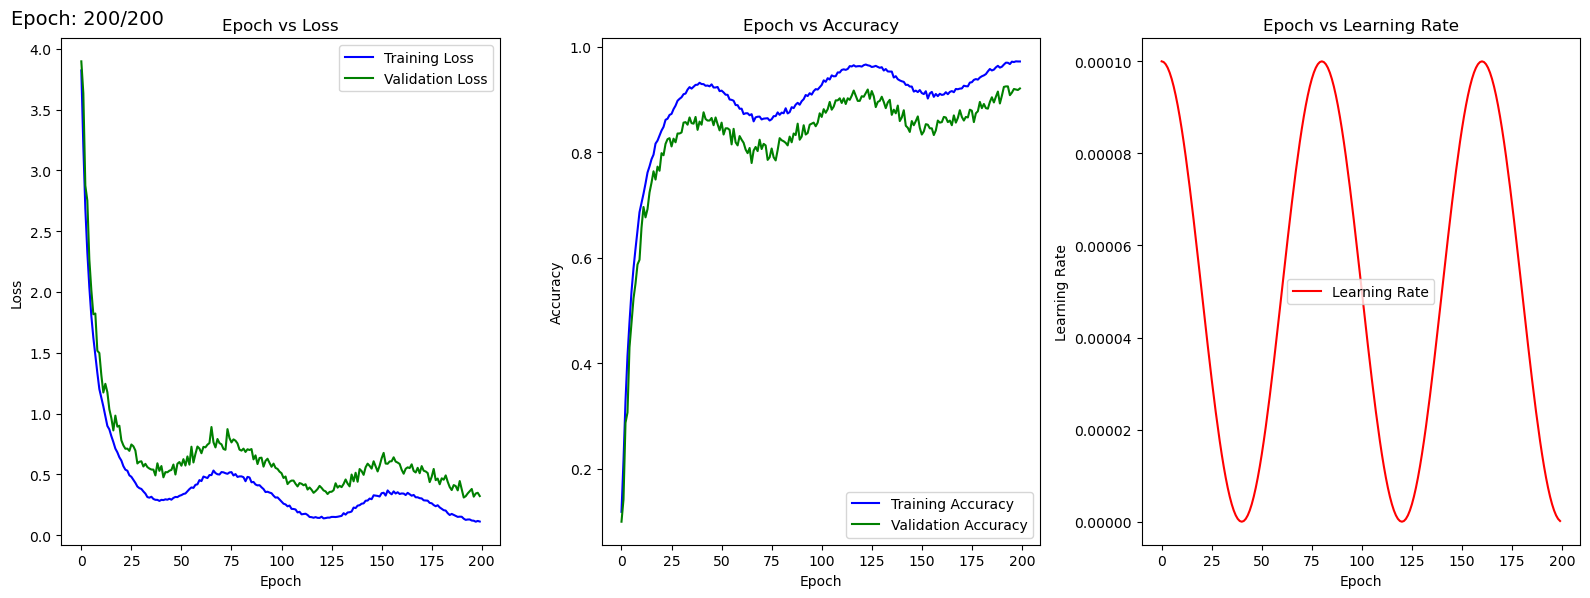

图像已保存为 'final_training_results.png'
learning_rate: 0.000000
train_losses: 0.1115
val_losses: 0.3212
train_accuracy: 97.17%
val_accuracy: 92.06%


In [24]:
# 嘗試從檢查點恢復
try:
    start_epoch, epoch_train_losses, epoch_val_losses, epoch_train_accuracies, epoch_val_accuracies, epoch_learning_rates = load_checkpoint('./checkpoint.pth')
except (FileNotFoundError, IndexError):
    print("沒有檢查點，從頭開始訓練。")
    start_epoch = 0
    epoch_train_losses, epoch_val_losses, epoch_train_accuracies, epoch_val_accuracies, epoch_learning_rates = [], [], [], [], []
    

def train_model(net, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        net.train()
        for images, labels in train_loader:
            # 将输入和目标转移到设备（GPU或CPU）
            images, labels = images.cuda(), labels.cuda()

            # 梯度清零
            optimizer.zero_grad()

            # 前向传播
            outputs = net(images)
            loss = criterion(outputs, labels)

            # 反向传播和优化
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct_predictions += (torch.max(outputs, 1)[1] == labels).sum().item()
            total_samples += labels.size(0)

        train_loss = running_loss / len(train_loader)  # 计算平均训练损失
        train_accuracy = correct_predictions / total_samples
        epoch_train_losses.append(train_loss)  # 保存每个epoch的训练集损失
        epoch_train_accuracies.append(train_accuracy)  # 保存每个epoch的训练集准确率

        val_loss, val_accuracy = evaluate_model(net, val_loader)
        epoch_val_losses.append(val_loss)  # 保存每个epoch的验证集损失
        epoch_val_accuracies.append(val_accuracy)  # 保存每个epoch的验证集准确率

        # 获取当前学习率并保存
        for param_group in optimizer.param_groups:
            current_lr = param_group['lr']
        epoch_learning_rates.append(current_lr)

        scheduler.step()
        # scheduler.step(val_loss)
        # print(f'Epoch [{epoch+1}/{start_epoch+num_epochs}], Loss: {avg_loss:.4f}, '
        #       f'Training Accuracy: {train_accuracy:.4f}, Validation Accuracy: {val_accuracy:.4f}')

        save_checkpoint({
            'epoch': epoch + 1,
            'model_state_dict': net.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': epoch_train_losses,
            'val_losses': epoch_val_losses,
            'train_accuracies': epoch_train_accuracies,
            'val_accuracies': epoch_val_accuracies,
            'learning_rates': epoch_learning_rates
        }, filename='checkpoint.pth')

        clear_output(wait=True)

        # 更新图表
        fig, axs = plt.subplots(1, 3, figsize=(16, 6))

        # 左上角添加 epoch 文本
        fig.text(0.01, 0.99, f'Epoch: {start_epoch + epoch + 1}/{start_epoch + num_epochs}', fontsize=14, verticalalignment='top')

        # 第一张图：训练集和验证集损失
        axs[0].plot(range(len(epoch_train_losses)), epoch_train_losses, label='Training Loss', color='blue')
        axs[0].plot(range(len(epoch_val_losses)), epoch_val_losses, label='Validation Loss', color='green')
        axs[0].set_xlabel('Epoch')
        axs[0].set_ylabel('Loss')
        axs[0].set_title('Epoch vs Loss')
        axs[0].legend()

        # 第二张图：训练集和验证集准确率
        axs[1].plot(range(len(epoch_train_accuracies)), epoch_train_accuracies, label='Training Accuracy', color='blue')
        axs[1].plot(range(len(epoch_val_accuracies)), epoch_val_accuracies, label='Validation Accuracy', color='green')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Accuracy')
        axs[1].set_title('Epoch vs Accuracy')
        axs[1].legend()

        # 第三张图：学习率
        axs[2].plot(range(len(epoch_learning_rates)), epoch_learning_rates, label='Learning Rate', color='red')
        axs[2].set_xlabel('Epoch')
        axs[2].set_ylabel('Learning Rate')
        axs[2].set_title('Epoch vs Learning Rate')
        axs[2].legend()

        plt.tight_layout()
        plt.savefig('final_training_results.png')  # 保存为最终结果图
        plt.show()
        plt.pause(0.1)  # 暂停以更新图表

    
    print("图像已保存为 'final_training_results.png'")
    print("learning_rate: {:.6f}".format(epoch_learning_rates[-1]))
    print("train_losses: {:.4f}".format(train_loss))
    print("val_losses: {:.4f}".format(val_loss))
    print("train_accuracy: {:.2f}%".format(train_accuracy*100))
    print("val_accuracy: {:.2f}%".format(val_accuracy*100))

train_model(net, train_loader, val_loader, criterion, optimizer, num_epochs=150-start_epoch)


In [38]:
print("[INFO] Using device: ",  torch.cuda.get_device_name(torch.cuda.current_device()), f", device num:{torch.cuda.current_device}")
net.load_state_dict(torch.load('./checkpoint.pth')['model_state_dict'])

def evaluate_model(net, test_loader):
    net.eval()  
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.cuda(), labels.cuda()
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy: {100 * correct / total:.2f}%')


evaluate_model(net, test_loader)

[INFO] Using device:  NVIDIA GeForce RTX 3090 , device num:<function current_device at 0x797af03c2160>


/tmp/ipykernel_692749/809517247.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load('./checkpoint.pth')['model_state_dict'])


Accuracy: 92.25%
